In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [7]:
print(df.columns)

Index(['Дата', 'Склад', 'Контрагент', 'Номенклатура', 'Количество'], dtype='object')


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Проверяем формат столбцов

In [9]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сразу переведем столбец "Дата" в правильный формат

In [10]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество_продаж')

print(grouped_df.head())

        Дата  Количество_продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


Сгруппируйте данные по дате, посчитайте количество продаж

Вывести несколько первых строк сгруппированных данных

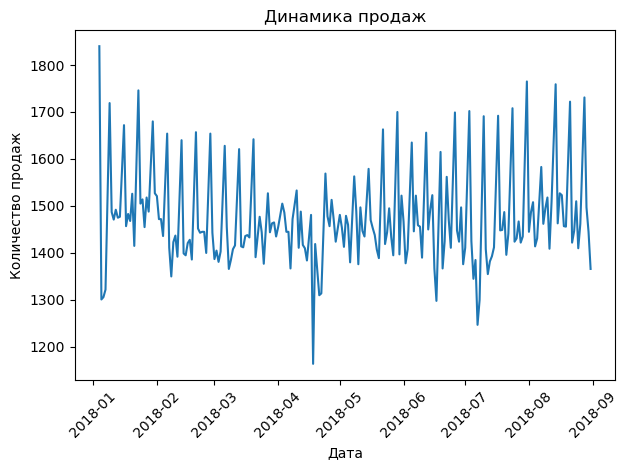

In [11]:
plt.figure()
plt.plot(grouped_df['Дата'], grouped_df['Количество_продаж'])
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.title('Динамика продаж')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Нарисуйте график продаж у `grouped_df`

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [12]:
max_row = df.loc[df['Количество'].idxmax()]
print("Строка с максимальным выбросом:")
print(max_row)

Строка с максимальным выбросом:
Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [13]:
df['weekday'] = df['Дата'].dt.weekday

summer_wed = df[
    (df['weekday'] == 2) &
    (df['Дата'].dt.month.isin([6, 7, 8]))
]
top_product = (
    summer_wed
    .groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
)
print("Топ товар по средам летом:")
print(top_product.head(1))

Топ товар по средам летом:
Номенклатура
product_1    12476
Name: Количество, dtype: int64


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [14]:
df["Месяц"] = df["Дата"].dt.month
df["День_недели"] = df["Дата"].dt.dayofweek

In [15]:
df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество,weekday,Месяц,День_недели
0,2018-01-04,1,address_0,product_0,4,3,1,3
1,2018-01-04,1,address_0,product_1,4,3,1,3
2,2018-01-04,1,address_0,product_2,5,3,1,3
3,2018-01-04,1,address_0,product_3,10,3,1,3
4,2018-01-04,1,address_0,product_4,2,3,1,3


In [16]:
wednesdays_jja = df.query("Склад == 3 and Месяц in [6, 7, 8] and День_недели == 2")
wednesdays_jja.head()

,Дата,Склад,Контрагент,Номенклатура,Количество,weekday,Месяц,День_недели
191165,2018-06-06,3,address_206,product_0,2,2,6,2
191166,2018-06-06,3,address_206,product_1,4,2,6,2
191167,2018-06-06,3,address_206,product_2,4,2,6,2
191168,2018-06-06,3,address_206,product_3,2,2,6,2
191169,2018-06-06,3,address_206,product_4,1,2,6,2


In [17]:
top_product = wednesdays_jja.groupby("Номенклатура")["Количество"].sum().idxmax()
total_quantity = wednesdays_jja.groupby("Номенклатура")["Количество"].sum().max()

In [18]:
print(f"Топовый товар по продажам по средам за инюь, июль и август у склада 3: {top_product} которого продана {total_quantity}")

Топовый товар по продажам по средам за инюь, июль и август у склада 3: product_1 которого продана 2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [111]:
import gzip

In [112]:
weather_raw = pd.read_csv(
    "weather.csv",
    sep=";",
    encoding="utf-8",
    skiprows=6,
    engine="python"
)

weather_raw.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,70 – 80%.,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,100%.,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [113]:
weather_raw = pd.read_csv("weather.csv", sep=";", encoding="utf-8", skiprows=6, engine="python")

In [114]:
weather = weather_raw.reset_index()

weather.head()

,index,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [115]:
weather = weather.iloc[:, [0, 1]]   # первый столбец (дата), второй (температура)
weather.columns = ["Дата", "T"]

In [116]:
weather.columns = ["Дата", "T"]
weather.columns

Index(['Дата', 'T'], dtype='object')

In [117]:
weather.dtypes

Дата     object
T       float64
dtype: object

In [118]:
weather["Дата"] = pd.to_datetime(weather["Дата"], dayfirst=True).dt.date
weather.dtypes

Дата     object
T       float64
dtype: object

In [119]:
weather.head()

,Дата,T
0,2018-08-31,8.2
1,2018-08-31,9.6
2,2018-08-31,11.3
3,2018-08-31,12.3
4,2018-08-31,13.2


In [120]:
daily_weather = weather.groupby("Дата")["T"].mean().reset_index()
daily_weather

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125
...,...,...
235,2018-08-27,12.5250
236,2018-08-28,14.1125
237,2018-08-29,13.8250
238,2018-08-30,14.1750


In [121]:
daily_weather.dtypes

Дата     object
T       float64
dtype: object

In [122]:
daily_weather['Дата'] = pd.to_datetime(daily_weather['Дата'])
daily_weather.dtypes

Дата    datetime64[ns]
T              float64
dtype: object

In [123]:
merged_df = pd.merge(grouped_df, daily_weather, on="Дата", how="inner")
merged_df.head()

,Дата,Количество_продаж,T
0,2018-01-04,1840,-14.0750
1,2018-01-05,1301,-16.8625
2,2018-01-06,1306,-13.3000
3,2018-01-07,1322,-12.7500
4,2018-01-09,1719,-6.2500


In [124]:
print(grouped_df["Дата"].min(), grouped_df["Дата"].max())
print(daily_weather["Дата"].min(), daily_weather["Дата"].max())

2018-01-04 00:00:00 2018-08-31 00:00:00
2018-01-04 00:00:00 2018-08-31 00:00:00


In [125]:
grouped_df.head()

,Дата,Количество_продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


In [126]:
daily_weather.head()

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [127]:
grouped_df.dtypes

Дата                 datetime64[ns]
Количество_продаж             int64
dtype: object

In [128]:
daily_weather.dtypes

Дата    datetime64[ns]
T              float64
dtype: object

In [129]:
temp_merged_df = merged_df.set_index("Дата")["T"].resample("ME").mean()
months = temp_merged_df.index.strftime("%b")

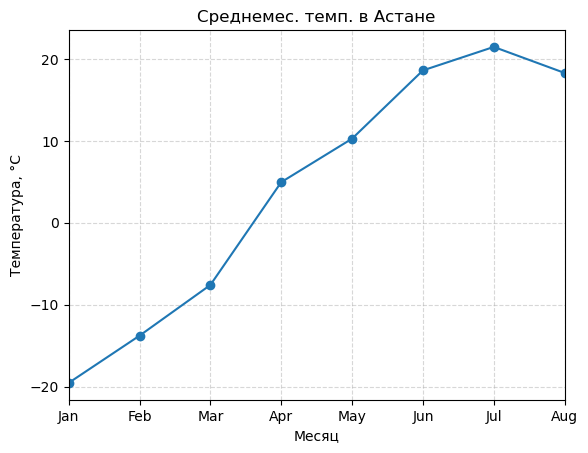

In [130]:
temp_merged_df.plot(kind="line", marker="o")
plt.xticks(ticks=temp_merged_df.index, labels=months[:len(temp_merged_df)])
plt.title('Среднемес. темп. в Астане')
plt.ylabel('Температура, °C')
plt.xlabel('Месяц')
plt.grid(alpha=0.5, linestyle="--")
plt.show()

In [133]:
monthly_df = (merged_df.resample("ME", on="Дата").agg({"T": "mean","Количество_продаж": "sum"}).reset_index())
monthly_df["Месяц"] = monthly_df["Дата"].dt.strftime("%b")
monthly_df.head()

,Дата,T,Количество_продаж,Месяц
0,2018-01-31,-19.542188,36344,Jan
1,2018-02-28,-13.777604,35176,Feb
2,2018-03-31,-7.590385,37653,Mar
3,2018-04-30,4.954000,35783,Apr
4,2018-05-31,10.263889,39679,May


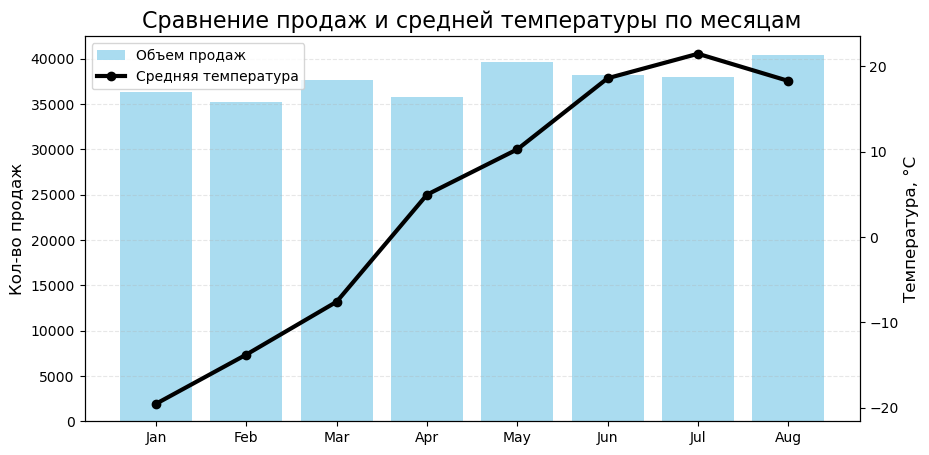

In [139]:
fig, ax_sales = plt.subplots(figsize=(10, 5))

ax_sales.bar(
    monthly_df["Месяц"],
    monthly_df["Количество_продаж"],
    color="skyblue",
    alpha=0.7,
    label="Объем продаж"
)

ax_sales.set_ylabel("Кол-во продаж", fontsize=12)

ax_temp = ax_sales.twinx()

ax_temp.plot(
    monthly_df["Месяц"],
    monthly_df["T"],
    color="black",
    marker="o",
    linewidth=3,
    label="Средняя температура"
)

ax_temp.set_ylabel("Температура, °C", fontsize=12)

plt.title("Сравнение продаж и средней температуры по месяцам", fontsize=16)

ax_sales.grid(axis="y", linestyle="--", alpha=0.3)

sales_handles, sales_labels = ax_sales.get_legend_handles_labels()
temp_handles, temp_labels = ax_temp.get_legend_handles_labels()

ax_sales.legend(
    sales_handles + temp_handles,
    sales_labels + temp_labels,
    loc="upper left"
)

plt.show()